In [1]:
# =============================================================================
# Notebook 6: Capability-based polar geometry (alternative realization)
# =============================================================================
# Tests whether the framework's results depend on text-embedding as the
# sole empirical realization. Constructs a parallel polar geometry directly
# from O*NET skill and ability values, and compares with the embedding-
# based geometry on three dimensions:
#
#   1. Spatial agreement: correlation of χ and ξ between realizations
#   2. Mediation pattern: does χ_cap have the same negative wage effect?
#   3. Sectoral structure: does the asymmetric polarization survive?
#
# Structure:
#   Cell 0  Setup (mirrors Notebook 4)
#   Cell 1  Build capability matrix and capability-based polar geometry
#   Cell 2  Align with embedding-based geometry (Procrustes)
#   Cell 3  Side-by-side map comparison
#   Cell 4  Correlation analysis (global and per-sector)
#   Cell 5  Mincer regression with χ_cap; compare to embedding result
# =============================================================================

# === Cell 0: Setup ===========================================================
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import infra
import embeddings
import overlays
importlib.reload(infra)
importlib.reload(embeddings)
importlib.reload(overlays)

infra.activate_last_run(echo=False)
RP, cfg, ENCODER_SPEC = infra.load_embeddings_run(strict=True)

SEED = 42
np.random.seed(SEED)

YEAR = int(cfg.get("year", 2025))
ONET_VERSION = str(cfg.get("onet_version", "30_0"))
ENCODER_NAME = str(cfg.get("encoder_name", "")).strip()

print("RUN_TAG      :", infra.RUN_TAG)
print("Exports      :", RP.exports)
print("Figures      :", RP.figures)
print("YEAR         :", YEAR)
print("ONET_VERSION :", ONET_VERSION)
print("ENCODER_NAME :", ENCODER_NAME)



RUN_TAG      : embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1
Exports      : /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports
Figures      : /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures
YEAR         : 2025
ONET_VERSION : 30_1
ENCODER_NAME : openai-3-large


In [2]:
# === Cell 1: Build capability-based polar geometry ===========================
import onet
from infra import log

db = onet.get_db(version=ONET_VERSION)
df_occ = infra.read_csv_any(
    RP.export_fp("occupation_embeddings_polar_scaled.csv")
)
occ_geom = overlays.prepare_occ_geometry(df_occ)

skills_overlay = overlays.compute_overlay(
    db=db, df_occ=df_occ, table_basename="Skills",
    label="skill", occ_geom=occ_geom,
)
abilities_overlay = overlays.compute_overlay(
    db=db, df_occ=df_occ, table_basename="Abilities",
    label="ability", occ_geom=occ_geom,
)

# Build combined capability matrix
skill_names = skills_overlay.chosen
abil_names = abilities_overlay.chosen
log(f"Skills: {len(skill_names)}, Abilities: {len(abil_names)}")

# Merge skills and abilities on onet_code
cap_df = skills_overlay.occ[["onet_code", "xi", "chi"] + skill_names].merge(
    abilities_overlay.occ[["onet_code"] + abil_names],
    on="onet_code", how="inner",
    suffixes=("", "_abil"),
)

# Drop occupations with any missing values
cap_df = cap_df.dropna(subset=skill_names + abil_names).reset_index(drop=True)
n_occ = len(cap_df)
log(f"Occupations with complete capability data: {n_occ}")

# Build standardized capability matrix
all_caps = skill_names + abil_names
V = cap_df[all_caps].to_numpy(float)

# Z-score per descriptor (so skills and abilities contribute on equal footing)
V_mean = V.mean(axis=0)
V_std = V.std(axis=0, ddof=1)
V_std = np.where(V_std > 0, V_std, 1.0)
V_z = (V - V_mean) / V_std

log(f"Capability matrix shape: {V_z.shape}")

# PCA via SVD
U, S, Vt = np.linalg.svd(V_z, full_matrices=False)
# Scores on first two components
scores = U[:, :2] * S[:2]
explained = (S ** 2) / (S ** 2).sum()
log(f"PC1 explained variance: {explained[0]:.3f}")
log(f"PC2 explained variance: {explained[1]:.3f}")
log(f"Top-2 cumulative:       {explained[:2].sum():.3f}")

# Capability-based polar coordinates
x_cap = scores[:, 0]
y_cap = scores[:, 1]
chi_cap_raw = np.hypot(x_cap, y_cap)
chi_cap = chi_cap_raw / chi_cap_raw.max()  # normalize to [0, 1]
xi_cap_raw = np.mod(np.arctan2(y_cap, x_cap), 2 * np.pi)

cap_df["x_cap_raw"] = x_cap
cap_df["y_cap_raw"] = y_cap
cap_df["xi_cap_raw"] = xi_cap_raw
cap_df["chi_cap"] = chi_cap

# Save loadings for interpretation
loadings = pd.DataFrame({
    "descriptor": all_caps,
    "loading_pc1": Vt[0],
    "loading_pc2": Vt[1],
})
loadings["family"] = ["skill"] * len(skill_names) + ["ability"] * len(abil_names)

# Inspect loadings — which descriptors define each PC
print("\n── Top 10 positive loadings on PC1 ──")
print(loadings.nlargest(10, "loading_pc1")[["descriptor", "family", "loading_pc1"]]
      .to_string(index=False))
print("\n── Top 10 negative loadings on PC1 ──")
print(loadings.nsmallest(10, "loading_pc1")[["descriptor", "family", "loading_pc1"]]
      .to_string(index=False))
print("\n── Top 10 positive loadings on PC2 ──")
print(loadings.nlargest(10, "loading_pc2")[["descriptor", "family", "loading_pc2"]]
      .to_string(index=False))
print("\n── Top 10 negative loadings on PC2 ──")
print(loadings.nsmallest(10, "loading_pc2")[["descriptor", "family", "loading_pc2"]]
      .to_string(index=False))

# Save intermediate output
out_csv = RP.exports / "capability_geometry_raw.csv"
cap_df.to_csv(out_csv, index=False)
print(f"\nSaved: {out_csv}")

out_csv = RP.exports / "capability_geometry_loadings.csv"
loadings.to_csv(out_csv, index=False)
print(f"Saved: {out_csv}")

• Overlay: Skills (LV) → 35 descriptors
• Overlay: Abilities (LV) → 52 descriptors
• Skills: 35, Abilities: 52
• Occupations with complete capability data: 878
• Capability matrix shape: (878, 87)
• PC1 explained variance: 0.480
• PC2 explained variance: 0.191
• Top-2 cumulative:       0.671

── Top 10 positive loadings on PC1 ──
             descriptor  family  loading_pc1
     Extent Flexibility ability     0.129895
        Static Strength ability     0.128864
       Dynamic Strength ability     0.127863
 Multilimb Coordination ability     0.126101
         Trunk Strength ability     0.123659
                Stamina ability     0.122796
Gross Body Coordination ability     0.121585
           Rate Control ability     0.119814
          Reaction Time ability     0.119777
       Manual Dexterity ability     0.119150

── Top 10 negative loadings on PC1 ──
           descriptor  family  loading_pc1
   Written Expression ability    -0.143320
             Speaking   skill    -0.142463
     

In [3]:
# === Cell 2: Procrustes alignment of capability geometry to embedding =======
# Capability PCA gives axes up to rotation/reflection. We align the
# capability-based polar coordinates to the embedding-based ones via
# orthogonal Procrustes on Cartesian centroid positions.

# Pull embedding-based xi/chi (already in cap_df as xi, chi)
xi_emb = cap_df["xi"].to_numpy(float)
chi_emb = cap_df["chi"].to_numpy(float)
x_emb = chi_emb * np.cos(xi_emb)
y_emb = chi_emb * np.sin(xi_emb)

# Capability-based Cartesian (already normalized: chi_cap in [0,1])
x_cap = cap_df["chi_cap"].to_numpy(float) * np.cos(cap_df["xi_cap_raw"].to_numpy(float))
y_cap = cap_df["chi_cap"].to_numpy(float) * np.sin(cap_df["xi_cap_raw"].to_numpy(float))

A_emb = np.column_stack([x_emb, y_emb])
A_cap = np.column_stack([x_cap, y_cap])

# Orthogonal Procrustes (with reflection allowed)
M = A_cap.T @ A_emb
U_p, _, Vt_p = np.linalg.svd(M)
R = U_p @ Vt_p   # 2x2 rotation matrix

# Apply
A_cap_aligned = A_cap @ R

# Convert back to polar
xi_cap_aligned = np.mod(np.arctan2(A_cap_aligned[:, 1], A_cap_aligned[:, 0]), 2 * np.pi)
chi_cap_aligned = np.hypot(A_cap_aligned[:, 0], A_cap_aligned[:, 1])

cap_df["xi_cap"] = xi_cap_aligned
cap_df["chi_cap_aligned"] = chi_cap_aligned

# Report alignment quality
def circ_distance(a, b):
    d = np.mod(a - b, 2 * np.pi)
    return np.minimum(d, 2 * np.pi - d)

dxi = circ_distance(xi_emb, xi_cap_aligned)
print(f"After Procrustes alignment:")
print(f"  Mean angular distance |ξ_emb − ξ_cap|: {np.degrees(dxi.mean()):.1f}°")
print(f"  Median:                              {np.degrees(np.median(dxi)):.1f}°")
print(f"  Fraction within 30°:                 {(dxi < np.pi/6).mean():.3f}")
print(f"  Fraction within 60°:                 {(dxi < np.pi/3).mean():.3f}")

# Correlations
from scipy.stats import spearmanr, pearsonr
r_xi_circ_cos = pearsonr(np.cos(xi_emb), np.cos(xi_cap_aligned))[0]
r_xi_circ_sin = pearsonr(np.sin(xi_emb), np.sin(xi_cap_aligned))[0]
r_chi, p_chi = spearmanr(chi_emb, chi_cap_aligned)

print(f"\n  Pearson cos(ξ_emb), cos(ξ_cap):   {r_xi_circ_cos:+.3f}")
print(f"  Pearson sin(ξ_emb), sin(ξ_cap):   {r_xi_circ_sin:+.3f}")
print(f"  Spearman χ_emb vs χ_cap:           {r_chi:+.3f}  (p = {p_chi:.2e})")

After Procrustes alignment:
  Mean angular distance |ξ_emb − ξ_cap|: 33.8°
  Median:                              23.4°
  Fraction within 30°:                 0.604
  Fraction within 60°:                 0.851

  Pearson cos(ξ_emb), cos(ξ_cap):   +0.807
  Pearson sin(ξ_emb), sin(ξ_cap):   +0.629
  Spearman χ_emb vs χ_cap:           +0.516  (p = 5.05e-61)


Saved: /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures/geometry_comparison_emb_vs_cap.png
Saved: /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures/geometry_comparison_emb_vs_cap.pdf


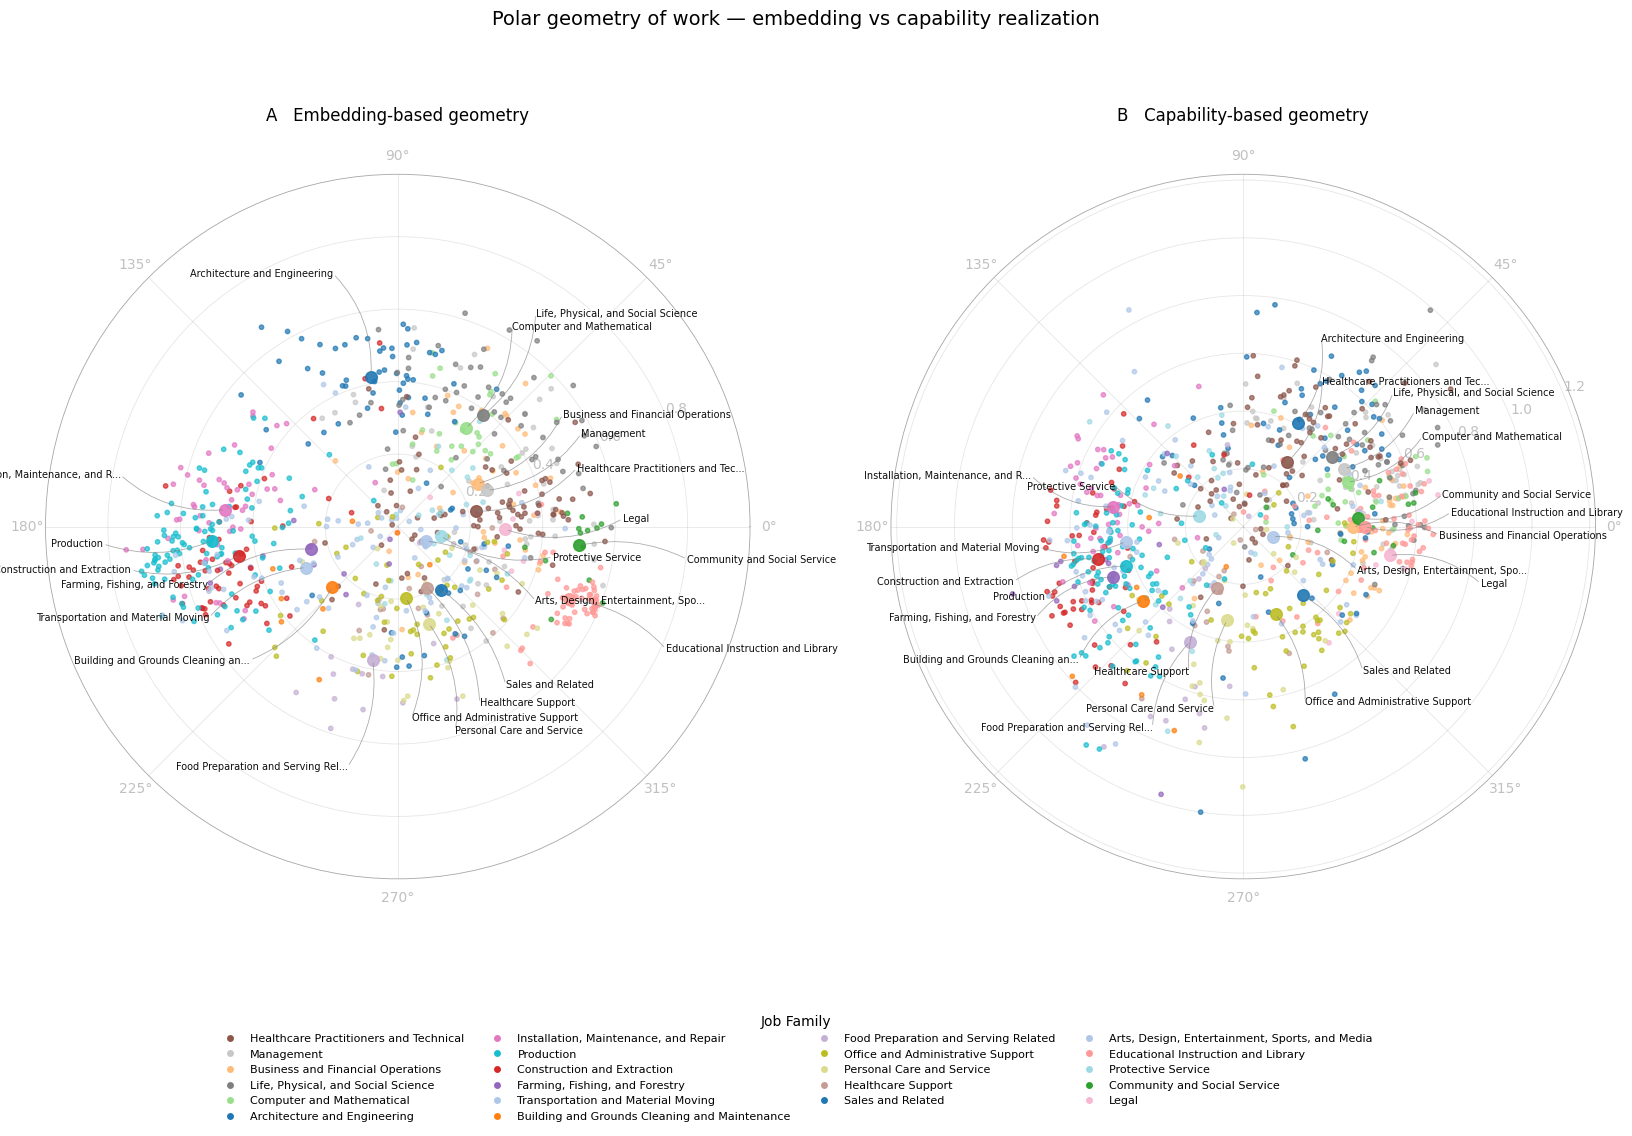

In [4]:
# === Cell 3: Side-by-side maps — embedding vs capability geometry ===========
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from plotutils import place_polar_labels_no_overlap_fast2

MAX_LABEL_LEN = 35
LABEL_SEED = 27

# ── Build Job Family centers for the capability geometry ──────────────────
# Need to merge in Job Family from the embedding-based occupation file
df_onet = infra.read_csv_any(RP.exports / "occupation_embeddings_polar_scaled.csv")
cap_df_with_fam = cap_df.merge(
    df_onet[["onet_code", "Job Family", "Title"]],
    on="onet_code", how="left"
)

# Capability-based family centers: weighted by 1 (simple mean for now)
fam_centers_cap = (
    cap_df_with_fam.dropna(subset=["Job Family"])
    .groupby("Job Family")
    .apply(lambda g: pd.Series({
        "xi_cap": np.arctan2(
            np.mean(g["chi_cap_aligned"] * np.sin(g["xi_cap"])),
            np.mean(g["chi_cap_aligned"] * np.cos(g["xi_cap"])),
        ) % (2 * np.pi),
        "chi_cap": np.hypot(
            np.mean(g["chi_cap_aligned"] * np.sin(g["xi_cap"])),
            np.mean(g["chi_cap_aligned"] * np.cos(g["xi_cap"])),
        ),
        "n_occ": len(g),
    }))
    .reset_index()
)

# Existing embedding-based family centers from saved file
df_famc_emb = infra.read_csv_any(RP.exports / "job_family_centers_polar_scaled.csv")

# ── Family color mapping (consistent across both panels) ──────────────────
unique_families = sorted(df_onet["Job Family"].dropna().unique())
family_to_idx = {fam: i for i, fam in enumerate(unique_families)}
base_cmap = plt.colormaps.get("tab20")
fam_cmap = [base_cmap(i % base_cmap.N) for i in range(len(unique_families))]


def _fam_color(fam):
    if pd.notna(fam) and fam in family_to_idx:
        return fam_cmap[family_to_idx[fam]]
    return (0.6, 0.6, 0.6)


# ── Plotting helper ───────────────────────────────────────────────────────
def plot_polar_geometry(ax, xi, chi, fam_series, fam_centers,
                          xi_col, chi_col, title, r_max):
    """Plot one polar geometry panel."""
    ax.set_axisbelow(True)

    AX_GRAY = (0.65, 0.65, 0.65)
    ax.grid(True, color=AX_GRAY, alpha=0.28, linewidth=0.6)
    ax.spines["polar"].set_color(AX_GRAY)
    ax.spines["polar"].set_linewidth(0.6)
    ax.tick_params(axis="x", colors=AX_GRAY, length=3, width=0.6)
    ax.tick_params(axis="y", colors=AX_GRAY, length=3, width=0.6)
    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_color(AX_GRAY)
        t.set_alpha(0.7)

    # Occupation points colored by job family
    colors = fam_series.map(_fam_color)
    mask = xi.notna() & chi.notna() & np.isfinite(xi) & np.isfinite(chi)
    ax.scatter(xi[mask].to_numpy(), chi[mask].to_numpy(),
               color=colors.loc[mask].to_list(),
               s=10, alpha=0.7, zorder=1, rasterized=True)

    # Family centers
    theta_list, chi_list, label_list, legend_data = [], [], [], []
    for _, row in fam_centers.iterrows():
        fam = row["Job Family"]
        if pd.isna(fam) or fam not in family_to_idx:
            continue
        theta = float(row[xi_col]) % (2 * np.pi)
        chi_val = float(row[chi_col])
        if not np.isfinite(theta) or not np.isfinite(chi_val):
            continue
        LABEL_CUT = MAX_LABEL_LEN - 3
        label = fam[:LABEL_CUT] + "..." if len(fam) > MAX_LABEL_LEN else fam
        fam_color = _fam_color(fam)
        ax.scatter(theta, chi_val, s=70, color=fam_color, alpha=0.90, zorder=3)
        theta_list.append(theta)
        chi_list.append(chi_val)
        label_list.append(label)
        legend_data.append((theta, fam, fam_color))

    # Wrap-around for label clustering
    if len(theta_list) >= 2:
        th = np.array(theta_list, dtype=float)
        if (th.min() < np.deg2rad(8)) and (th.max() > (2 * np.pi - np.deg2rad(8))):
            th2 = th.copy()
            th2[th2 < np.deg2rad(8)] += 2 * np.pi
            theta_for_labels = th2.tolist()
        else:
            theta_for_labels = theta_list
    else:
        theta_for_labels = theta_list

    place_polar_labels_no_overlap_fast2(
        ax, theta_for_labels, chi_list, label_list,
        base_offset=0.30, fontsize=7, max_iter=60,
        step_r_px=3.0, step_t_px=2.5,
        rlim_pad=0.08, edge_softzone=0.12,
        theta_bias_at_edge=3.0, return_spring=0.20,
        seed=LABEL_SEED, init_jitter_px=6.0,
        collision_jitter=0.25, safety_iters=12,
    )

    ax.set_rlim(0, r_max + 0.22)
    ax.set_title(title, fontsize=12, pad=20)

    return legend_data


# ── Two-panel figure ─────────────────────────────────────────────────────
fig, (ax_emb, ax_cap) = plt.subplots(
    1, 2, figsize=(20, 11),
    subplot_kw={"projection": "polar"}
)

# Panel A: embedding-based geometry
xi_emb_series = pd.to_numeric(cap_df_with_fam["xi"], errors="coerce")
chi_emb_series = pd.to_numeric(cap_df_with_fam["chi"], errors="coerce")
r_max_emb = float(np.nanmax([chi_emb_series.max(), df_famc_emb["chi"].max()]))

legend_data_emb = plot_polar_geometry(
    ax_emb,
    xi_emb_series, chi_emb_series,
    cap_df_with_fam["Job Family"],
    df_famc_emb,
    "xi", "chi",
    "A   Embedding-based geometry",
    r_max_emb,
)

# Panel B: capability-based geometry
xi_cap_series = pd.to_numeric(cap_df_with_fam["xi_cap"], errors="coerce")
chi_cap_series = pd.to_numeric(cap_df_with_fam["chi_cap_aligned"], errors="coerce")
r_max_cap = float(np.nanmax([chi_cap_series.max(), fam_centers_cap["chi_cap"].max()]))

legend_data_cap = plot_polar_geometry(
    ax_cap,
    xi_cap_series, chi_cap_series,
    cap_df_with_fam["Job Family"],
    fam_centers_cap,
    "xi_cap", "chi_cap",
    "B   Capability-based geometry",
    r_max_cap,
)

# Shared legend (sorted by embedding-based angle for consistency)
legend_data_sorted = sorted(legend_data_emb, key=lambda x: x[0])
legend_elements = [
    Line2D([0], [0], marker="o", color="w", label=fam,
           markerfacecolor=color, markersize=6)
    for _, fam, color in legend_data_sorted
]
fig.legend(handles=legend_elements,
           loc="lower center", bbox_to_anchor=(0.5, -0.02),
           ncol=4, title="Job Family", fontsize=8, frameon=False)

fig.suptitle("Polar geometry of work — embedding vs capability realization",
             fontsize=14, y=1.00)
fig.subplots_adjust(bottom=0.18)

out_png = RP.figures / "geometry_comparison_emb_vs_cap.png"
out_pdf = RP.figures / "geometry_comparison_emb_vs_cap.pdf"
fig.savefig(out_png, dpi=300, bbox_inches="tight")
fig.savefig(out_pdf, dpi=300, bbox_inches="tight")
print(f"Saved: {out_png}")
print(f"Saved: {out_pdf}")
plt.show()